In [36]:
from pyspark.sql.functions import col,count
from pyspark.sql import SparkSession
from delta.tables import *

spark = (
    SparkSession.builder
    .appName("App_Traffic_Visualizer")
    .config("spark.jars.packages", "io.delta:delta-spark_2.13:4.0.0")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .getOrCreate()
)

Usage_df=spark.read.format("delta").load("/home/victus/Fahad/Kafka/App_Traffic_Monitor/App_Traffic_Delta")

s_df=Usage_df.groupBy("state").agg(count(col("event")).alias("app_traffic"))
df = s_df.toPandas()

df.head()

,state,app_traffic
0,Odisha,3
1,Chhattisgarh,2
2,Lakshadweep,2
3,Punjab,4
4,DadraandNagarHaveli,5


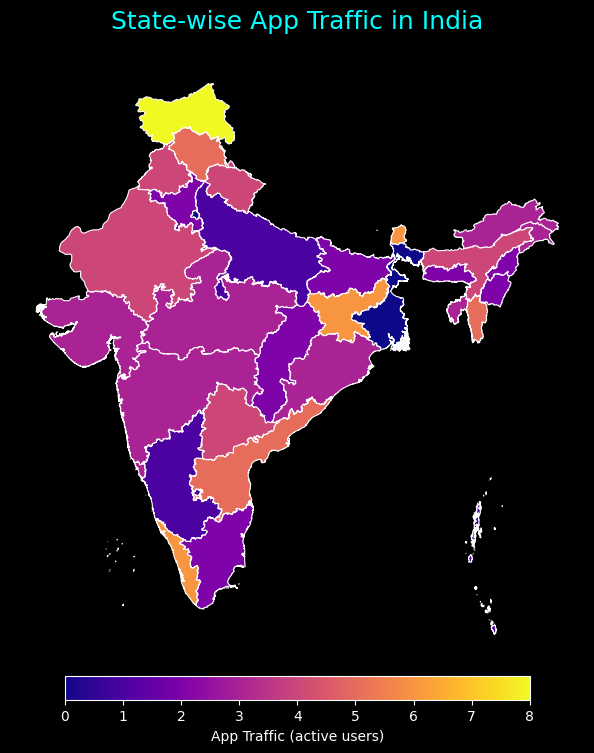

In [37]:
import matplotlib.pyplot as plt
import geopandas as gpd


# India states shapefile
india_states = gpd.read_file("/home/victus/Fahad/Kafka/App_Traffic_Monitor/Look_UP_Data/gadm41_IND_1.json")


# Merge with shapefile
india_states = india_states.merge(df, left_on="NAME_1", right_on="state", how="left")
india_states['app_traffic'] = india_states['app_traffic'].fillna(0)

# Plot style
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

india_states.plot(
    column="app_traffic",
    cmap="plasma",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "App Traffic (active users)",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02
    },
    missing_kwds={
        "color": "grey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No Data"
    },
    ax=ax
)


ax.set_title("State-wise App Traffic in India", fontsize=18, color="cyan", pad=20)
ax.axis("off")

plt.subplots_adjust(bottom=0.15)
plt.show()

In [38]:
from branca.colormap import linear
import folium



colormap = linear.plasma.scale(
    india_states["app_traffic"].min(skipna=True),
    india_states["app_traffic"].max(skipna=True)
)
colormap.caption = "App Traffic (users/sessions)"

# folium map
m = folium.Map(location=[22.5, 80], zoom_start=5, tiles="cartodb dark_matter")


folium.GeoJson(
    india_states,
    style_function=lambda feature: {
        "fillColor": (
            colormap(feature["properties"]["app_traffic"])
            if feature["properties"]["app_traffic"] is not None
            else "grey"   # No data
        ),
        "color": "white",
        "weight": 1,
        "dashArray": "3",
        "fillOpacity": 0.8,
    },
    highlight_function=lambda x: {"weight": 3, "color": "cyan"},
    tooltip=folium.GeoJsonTooltip(
        fields=["NAME_1", "app_traffic"],
        aliases=["State/UT:", "App Traffic:"],
        localize=True,
        sticky=True,
        labels=True,
        style=(
            "background-color: black; color: cyan; "
            "font-family: monospace; font-size: 13px; padding: 5px;"
        )
    )
).add_to(m)

colormap.add_to(m)

m.save("/home/victus/Fahad/Kafka/App_Traffic_Monitor/India_app_traffic.html")
print("✅ Interactive map saved as india_app_traffic.html")


✅ Interactive map saved as india_app_traffic.html
